In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("churn_df_copy.csv")

# ==========================
# TASK 2 : EDA
# ==========================

# 2.1 Overall Churn Rate
# 2.2 Customer Distribution
# 2.3 Tenure Analysis
# 2.4 Contract Type Analysis
# 2.5 Payment Method Analysis
# 2.6 Key Insights

In [3]:

# 2.1 Overall Churn Rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


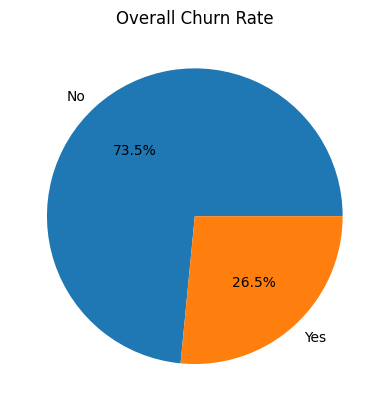

In [4]:

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Overall Churn Rate')
plt.ylabel('')
plt.show()

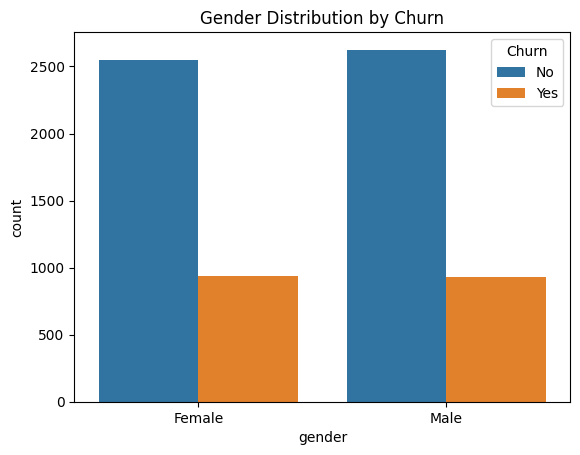

In [5]:
sns.countplot(
    data=df,
    x='gender',
    hue='Churn'
)

plt.title('Gender Distribution by Churn')
plt.show()

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
pd.crosstab(df['gender'], df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [8]:
gender_churn = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


Gender does not appear to be a strong driver of customer churn.

In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

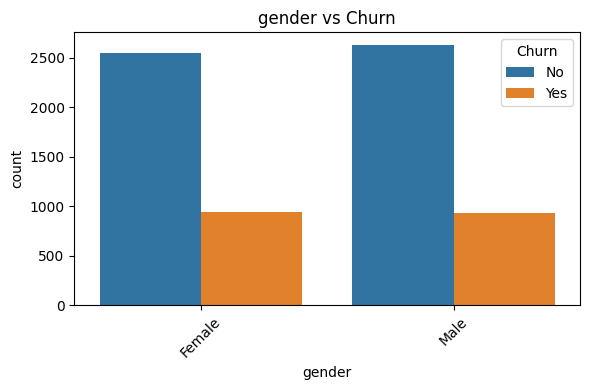

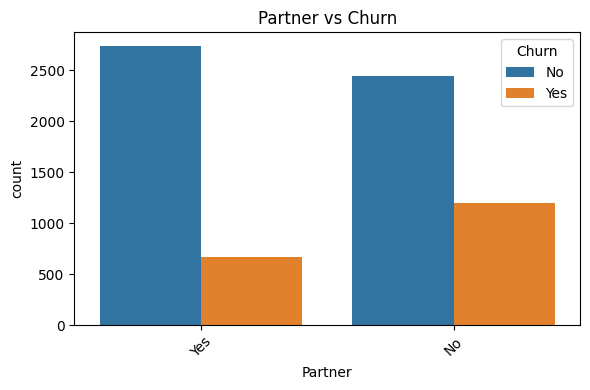

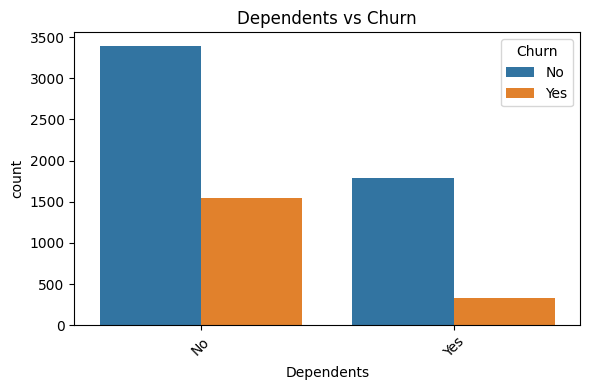

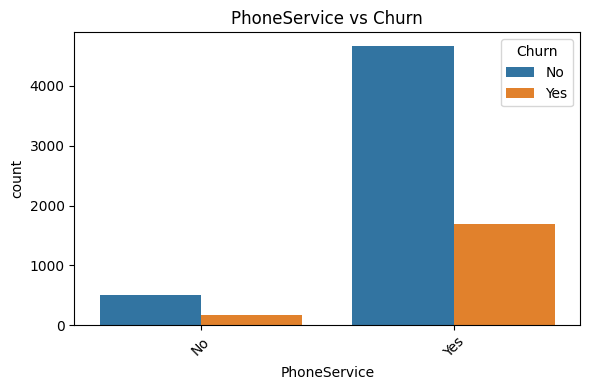

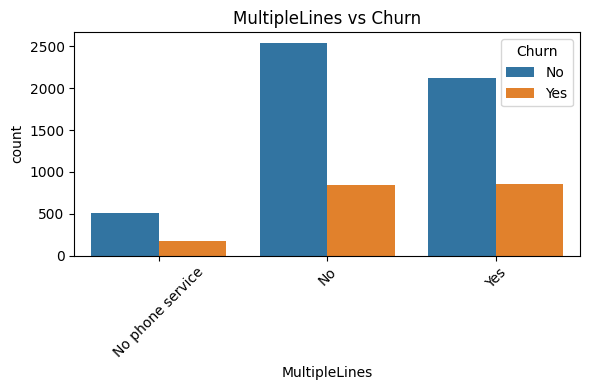

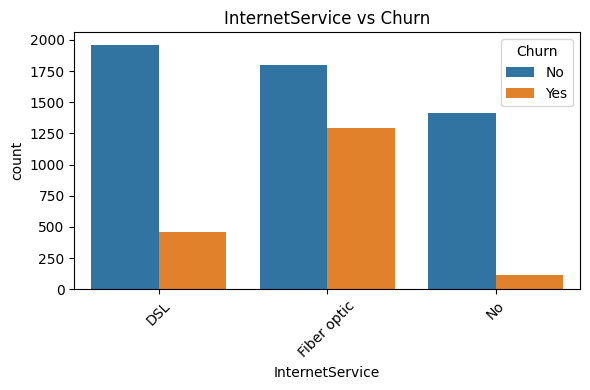

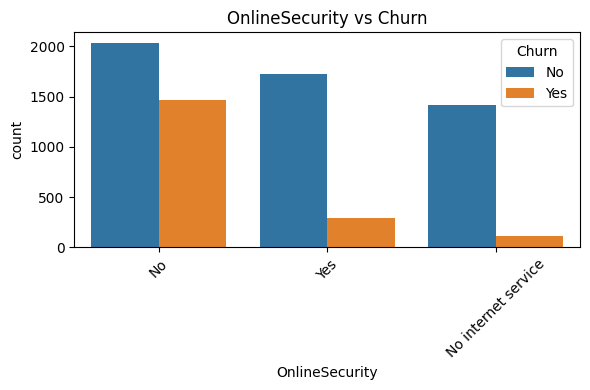

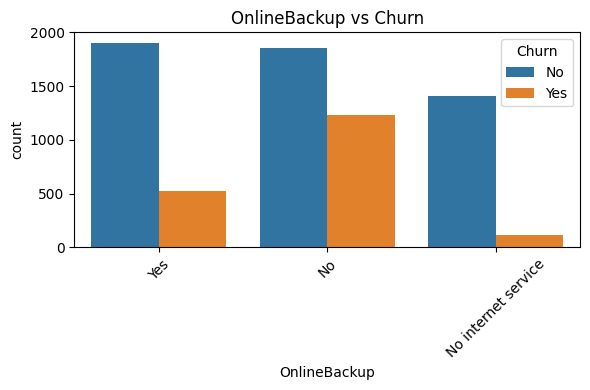

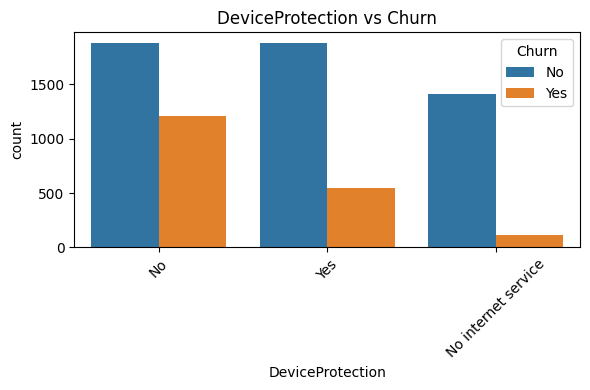

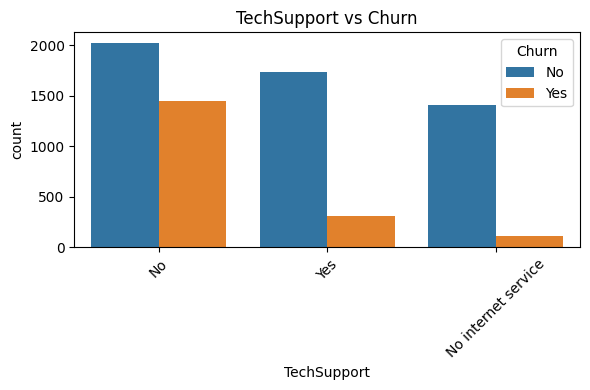

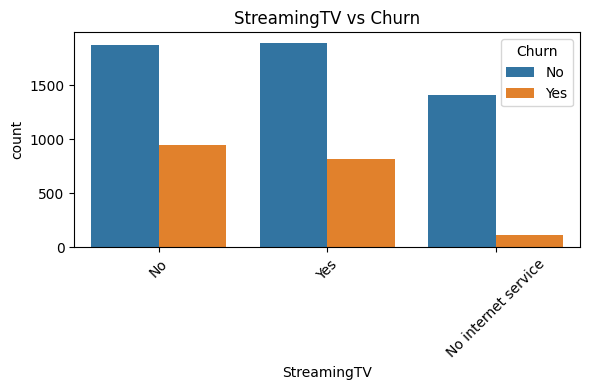

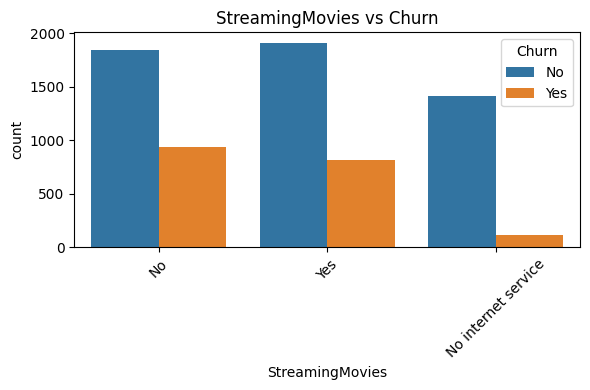

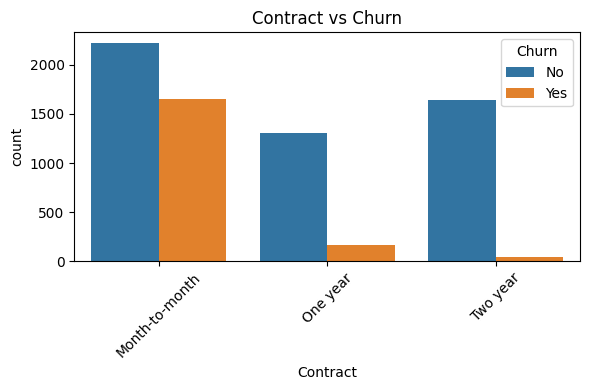

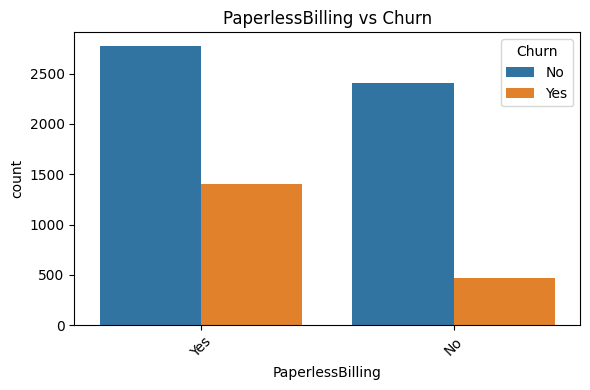

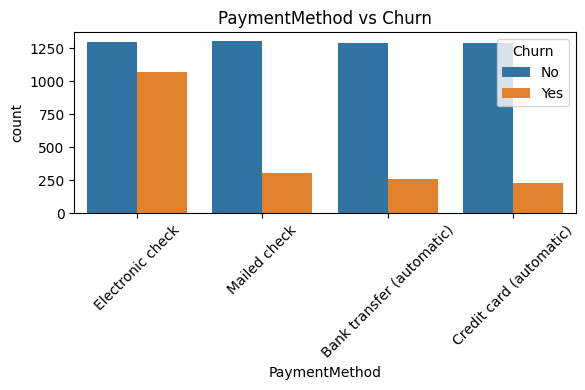

In [11]:

categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [14]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [15]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [16]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100 

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [17]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [18]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


<Axes: xlabel='tenure', ylabel='Count'>

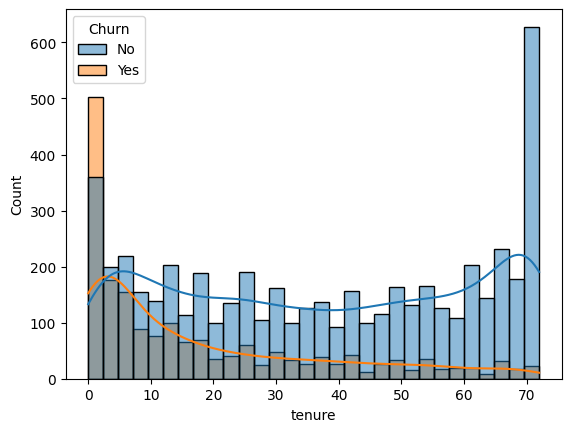

In [19]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

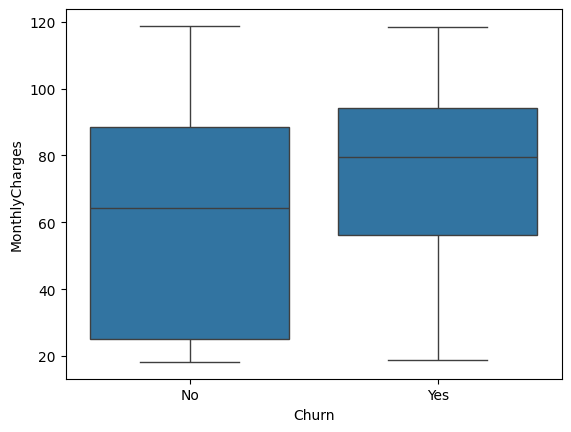

In [20]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

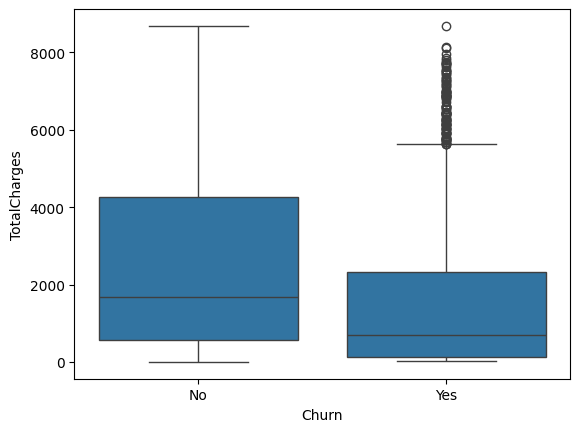

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

sns.boxplot(data=df, x='Churn', y='TotalCharges')

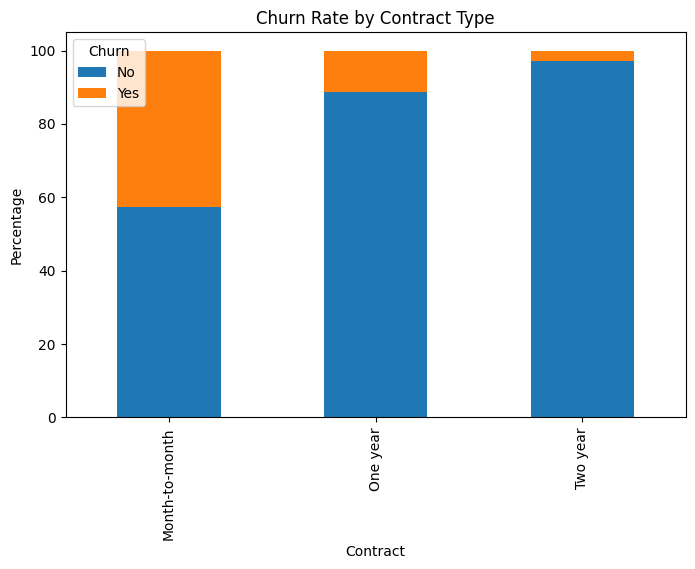

In [7]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.ylabel("Percentage")
plt.title("Churn Rate by Contract Type")
plt.show()